In [2]:
# ============================================================
# MSIS 522 HW1 — PaySim Fraud Dataset
# File: data.csv
# ============================================================

import pandas as pd

# ----------------------------
# 1) Load the dataset
# ----------------------------
FILE_PATH = "data.csv"
df = pd.read_csv(FILE_PATH)

print("✅ Loaded dataset:", FILE_PATH)
print("Shape (rows, cols):", df.shape)
display(df.head(5))
print("\nColumn dtypes:")
display(df.dtypes)

# ----------------------------
# 2) Confirm expected columns
# ----------------------------
expected_cols = [
    "step", "type", "amount", "nameOrig",
    "oldbalanceOrg", "newbalanceOrig",
    "nameDest", "oldbalanceDest", "newbalanceDest",
    "isFraud", "isFlaggedFraud"
]

missing_expected = [c for c in expected_cols if c not in df.columns]
if missing_expected:
    print("\n⚠️ These expected PaySim columns were NOT found (check your CSV):")
    print(missing_expected)
else:
    print("\n✅ All expected PaySim columns found.")

# ----------------------------
# 3) Basic missing values check
# ----------------------------
print("\nMissing value % (top 10 columns):")
display((df.isna().mean() * 100).sort_values(ascending=False).head(10))

# ----------------------------
# 4) Target distribution (fraud rate)
# ----------------------------
print("\nTarget distribution (counts):")
display(df["isFraud"].value_counts())

print("\nTarget distribution (fraud rate):")
display(df["isFraud"].value_counts(normalize=True))

# ----------------------------
# 5) Sample for speed
# ----------------------------
# Full PaySim is ~6.3M rows. Sampling keeps training + plots fast.
SAMPLE_N = 800_000

if len(df) > SAMPLE_N:
    df = df.sample(SAMPLE_N, random_state=42).reset_index(drop=True)
    print(f"\n✅ Sampled to {SAMPLE_N:,} rows for faster modeling/EDA.")
else:
    print(f"\n✅ Dataset has <= {SAMPLE_N:,} rows; no sampling needed.")

print("Sampled shape:", df.shape)

# ----------------------------
# 6) Sanity check: Fraud rate by transaction type
# ----------------------------
# EDA insight: in PaySim, fraud usually concentrates in certain types (often TRANSFER/CASH_OUT).
fraud_by_type = pd.crosstab(df["type"], df["isFraud"], normalize="index")
fraud_by_type.columns = ["NonFraud_rate", "Fraud_rate"]
fraud_by_type = fraud_by_type.sort_values("Fraud_rate", ascending=False)

print("\nFraud rate by transaction type:")
display(fraud_by_type)

# ----------------------------
# 7) Creating a few helpful engineered features
# ----------------------------
df["orig_balance_delta"] = df["oldbalanceOrg"] - df["newbalanceOrig"]
df["dest_balance_delta"] = df["newbalanceDest"] - df["oldbalanceDest"]

print("\n✅ Added engineered features: orig_balance_delta, dest_balance_delta")
display(df[["oldbalanceOrg", "newbalanceOrig", "orig_balance_delta",
            "oldbalanceDest", "newbalanceDest", "dest_balance_delta"]].head(5))

# ----------------------------
# 8) Save the sampled dataframe
# ----------------------------

SAMPLED_OUT = "data_sampled.csv"
df.to_csv(SAMPLED_OUT, index=False)
print(f"\n✅ Saved sampled dataset to: {SAMPLED_OUT}")

✅ Loaded dataset: data.csv
Shape (rows, cols): (1428261, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0



Column dtypes:


,0
step,int64
type,object
amount,float64
nameOrig,object
oldbalanceOrg,float64
newbalanceOrig,float64
nameDest,object
oldbalanceDest,float64
newbalanceDest,float64
isFraud,float64



✅ All expected PaySim columns found.

Missing value % (top 10 columns):


...


✅ Sampled to 800,000 rows for faster modeling/EDA.
Sampled shape: (800000, 11)

Fraud rate by transaction type:


,NonFraud_rate,Fraud_rate
type,,
TRANSFER,0.993325,0.006675
CASH_OUT,0.998427,0.001573
CASH_IN,1.000000,0.000000
DEBIT,1.000000,0.000000
PAYMENT,1.000000,0.000000



✅ Added engineered features: orig_balance_delta, dest_balance_delta


,oldbalanceOrg,newbalanceOrig,orig_balance_delta,oldbalanceDest,newbalanceDest,dest_balance_delta
0,87028.60,40080.65,46947.95,0.00,0.00,0.00
1,0.00,0.00,0.00,0.00,0.00,0.00
2,117.00,0.00,117.00,12200.00,54460.74,42260.74
3,1660858.93,1778607.01,-117748.08,545616.12,168630.16,-376985.96
4,9916.00,130321.99,-120405.99,0.00,0.00,0.00



✅ Saved sampled dataset to: data_sampled.csv


In [3]:
# =========================
# Part 1.1 — Dataset Intro
# =========================
import numpy as np

target = "isFraud"

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nTarget:", target)
print("Fraud rate:", df[target].mean())

# Feature type summary
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()

print("\nNumerical columns:", len(num_cols))
print("Categorical columns:", len(cat_cols))
print("\nCategorical columns:", cat_cols)

Rows: 800000
Columns: 13

Target: isFraud
Fraud rate: 0.00111625

Numerical columns: 10
Categorical columns: 3

Categorical columns: ['type', 'nameOrig', 'nameDest']


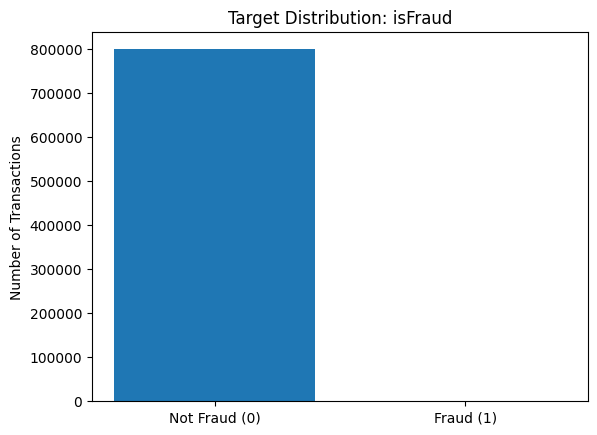

Class counts:
 isFraud
0.0    799107
1.0       893
Name: count, dtype: int64
Fraud rate: 0.00111625


In [4]:
# =========================
# Part 1.2 — Target Plot
# =========================
import matplotlib.pyplot as plt

counts = df["isFraud"].value_counts().sort_index()

plt.figure()
plt.bar(["Not Fraud (0)", "Fraud (1)"], counts.values)
plt.title("Target Distribution: isFraud")
plt.ylabel("Number of Transactions")
plt.show()

print("Class counts:\n", counts)
print("Fraud rate:", df["isFraud"].mean())

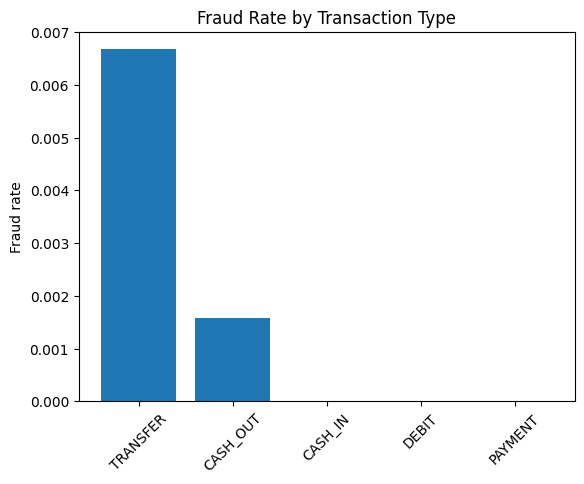

,1.0
type,
TRANSFER,0.006675
CASH_OUT,0.001573
CASH_IN,0.000000
DEBIT,0.000000
PAYMENT,0.000000


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

type_fraud = pd.crosstab(df["type"], df["isFraud"], normalize="index")[1].sort_values(ascending=False)

plt.figure()
plt.bar(type_fraud.index.astype(str), type_fraud.values)
plt.title("Fraud Rate by Transaction Type")
plt.ylabel("Fraud rate")
plt.xticks(rotation=45)
plt.show()

type_fraud

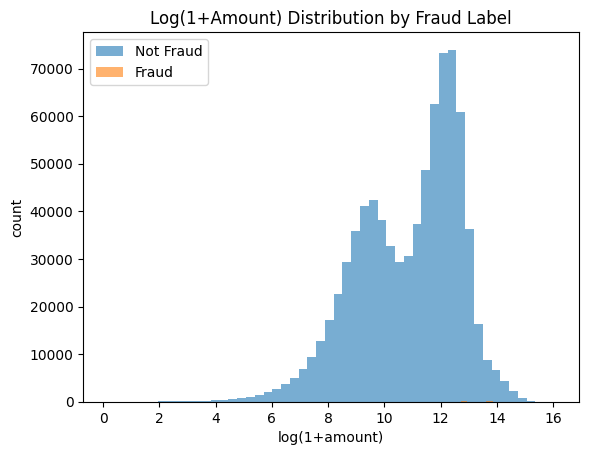

In [6]:
import numpy as np

df_plot = df.copy()
df_plot["log_amount"] = np.log1p(df_plot["amount"])

plt.figure()
plt.hist(df_plot[df_plot["isFraud"]==0]["log_amount"], bins=50, alpha=0.6, label="Not Fraud")
plt.hist(df_plot[df_plot["isFraud"]==1]["log_amount"], bins=50, alpha=0.6, label="Fraud")
plt.title("Log(1+Amount) Distribution by Fraud Label")
plt.xlabel("log(1+amount)")
plt.ylabel("count")
plt.legend()
plt.show()

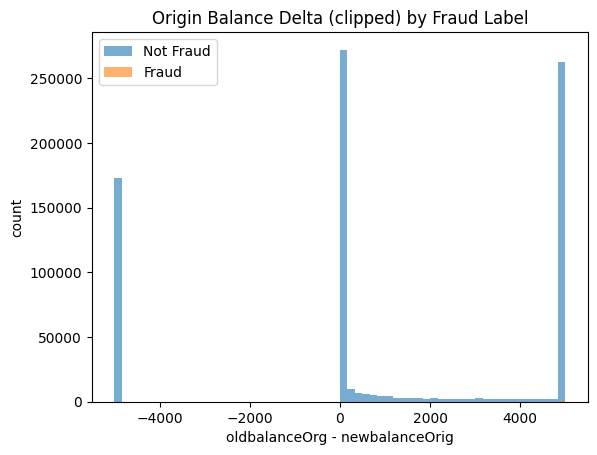

In [7]:
plt.figure()
plt.hist(np.clip(df[df["isFraud"]==0]["orig_balance_delta"], -5000, 5000), bins=60, alpha=0.6, label="Not Fraud")
plt.hist(np.clip(df[df["isFraud"]==1]["orig_balance_delta"], -5000, 5000), bins=60, alpha=0.6, label="Fraud")
plt.title("Origin Balance Delta (clipped) by Fraud Label")
plt.xlabel("oldbalanceOrg - newbalanceOrig")
plt.ylabel("count")
plt.legend()
plt.show()

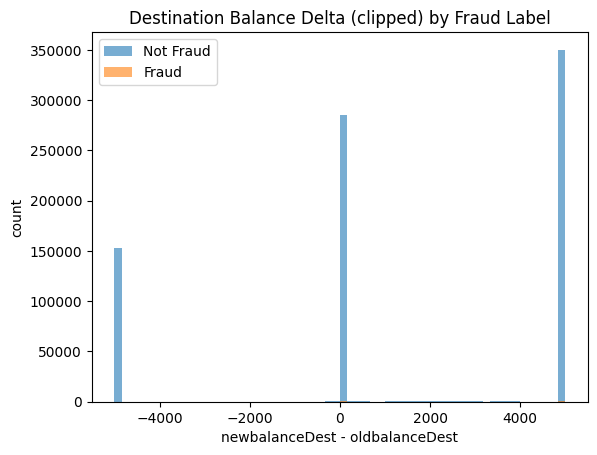

In [8]:
plt.figure()
plt.hist(np.clip(df[df["isFraud"]==0]["dest_balance_delta"], -5000, 5000), bins=60, alpha=0.6, label="Not Fraud")
plt.hist(np.clip(df[df["isFraud"]==1]["dest_balance_delta"], -5000, 5000), bins=60, alpha=0.6, label="Fraud")
plt.title("Destination Balance Delta (clipped) by Fraud Label")
plt.xlabel("newbalanceDest - oldbalanceDest")
plt.ylabel("count")
plt.legend()
plt.show()

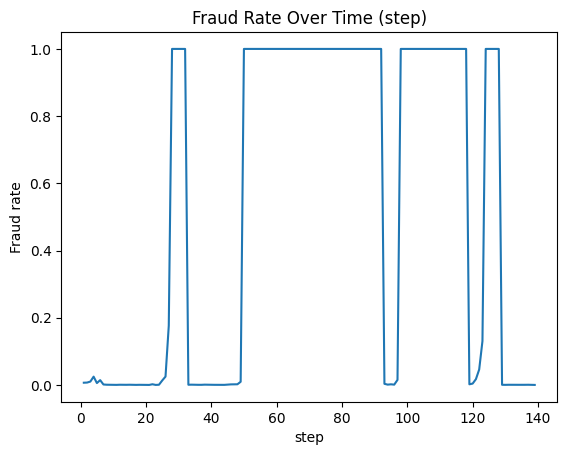

In [9]:
fraud_by_step = df.groupby("step")["isFraud"].mean()

plt.figure()
plt.plot(fraud_by_step.index, fraud_by_step.values)
plt.title("Fraud Rate Over Time (step)")
plt.xlabel("step")
plt.ylabel("Fraud rate")
plt.show()

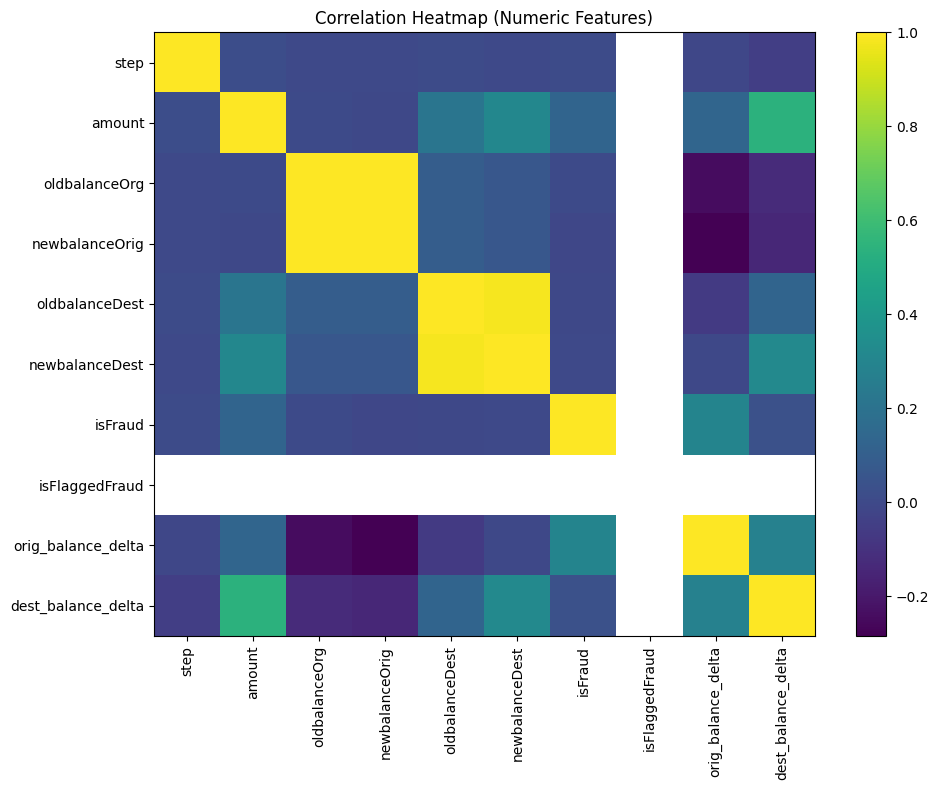

Top correlations with isFraud:


,isFraud
isFraud,1.000000
orig_balance_delta,0.295151
amount,0.128748
dest_balance_delta,0.035882
step,0.007844
oldbalanceOrg,0.004105
newbalanceDest,0.000031
oldbalanceDest,-0.007285
newbalanceOrig,-0.009479
isFlaggedFraud,NaN


,isFraud
isFraud,1.000000
orig_balance_delta,0.295151
amount,0.128748
dest_balance_delta,0.035882
step,0.007844
oldbalanceOrg,0.004105
newbalanceDest,0.000031
oldbalanceDest,-0.007285
newbalanceOrig,-0.009479
isFlaggedFraud,NaN


In [10]:
# =========================
# Part 1.4 — Correlation
# =========================
import numpy as np
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include=np.number).copy()
corr = numeric_df.corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.title("Correlation Heatmap (Numeric Features)")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.tight_layout()
plt.show()

# Show strongest correlations with target
target_corr = corr["isFraud"].sort_values(ascending=False)
print("Top correlations with isFraud:")
display(target_corr.head(10))
display(target_corr.tail(10))

In [11]:
# =========================
# Part 2 — Setup
# =========================
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

TARGET = "isFraud"

# Features: drop IDs and the other label-ish column
drop_cols = [TARGET, "isFlaggedFraud", "nameOrig", "nameDest"]  # keep it simple + generalizable
X = df.drop(columns=drop_cols)
y = df[TARGET].astype(int)

# Stratified split is IMPORTANT for rare fraud cases
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train fraud rate:", y_train.mean(), "Test fraud rate:", y_test.mean())

# Identify numeric vs categorical
num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

print("Numeric cols:", len(num_cols))
print("Categorical cols:", len(cat_cols), cat_cols)

# Preprocessing: impute + scale numeric; impute + one-hot encode categorical
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ],
    remainder="drop"
)

Train shape: (560000, 9) Test shape: (240000, 9)
Train fraud rate: 0.0011160714285714285 Test fraud rate: 0.0011166666666666666
Numeric cols: 8
Categorical cols: 1 ['type']


In [12]:
# =========================
# Evaluation Helpers
# =========================
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay, average_precision_score
)

def eval_binary_classifier(name, model, X_test, y_test):
    """Returns a dict of key test metrics (also prints a short summary)."""
    y_pred = model.predict(X_test)


    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, y_score),
        "PR_AUC": average_precision_score(y_test, y_score)
    }

    print(f"\n=== {name} ===")
    for k, v in metrics.items():
        if k != "Model":
            print(f"{k}: {v:.4f}")

    return metrics

def plot_roc_pr(model, X_test, y_test, title_prefix=""):
    plt.figure()
    RocCurveDisplay.from_estimator(model, X_test, y_test)
    plt.title(f"{title_prefix} ROC Curve")
    plt.show()

    plt.figure()
    PrecisionRecallDisplay.from_estimator(model, X_test, y_test)
    plt.title(f"{title_prefix} Precision-Recall Curve")
    plt.show()


=== Logistic Regression ===
Accuracy: 0.9402
Precision: 0.0179
Recall: 0.9739
F1: 0.0351
ROC_AUC: 0.9845
PR_AUC: 0.5846


<Figure size 640x480 with 0 Axes>

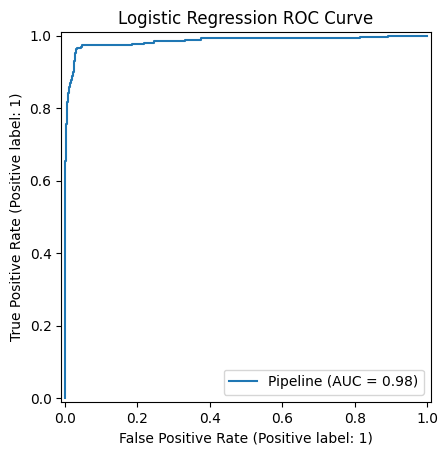

<Figure size 640x480 with 0 Axes>

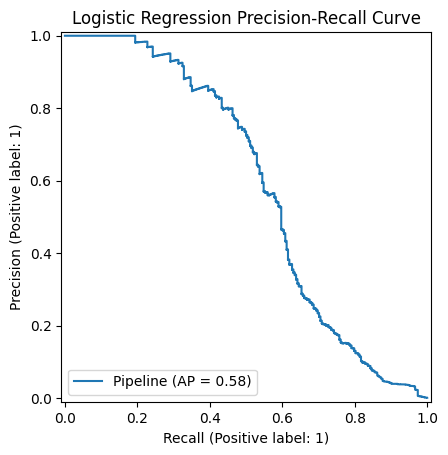

In [13]:
# =========================
# 2.2 Logistic Regression Baseline
# =========================
from sklearn.linear_model import LogisticRegression

lr = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42))
])

lr.fit(X_train, y_train)

results = []
results.append(eval_binary_classifier("Logistic Regression", lr, X_test, y_test))
plot_roc_pr(lr, X_test, y_test, "Logistic Regression")

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Tree Params: {'model__max_depth': 10, 'model__min_samples_leaf': 50}

=== Decision Tree (CV) ===
Accuracy: 0.9916
Precision: 0.1104
Recall: 0.9254
F1: 0.1973
ROC_AUC: 0.9614
PR_AUC: 0.6222


<Figure size 640x480 with 0 Axes>

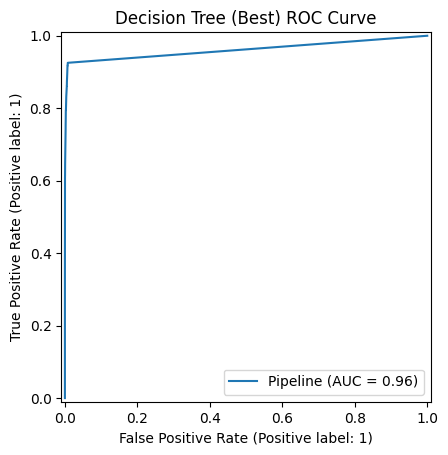

<Figure size 640x480 with 0 Axes>

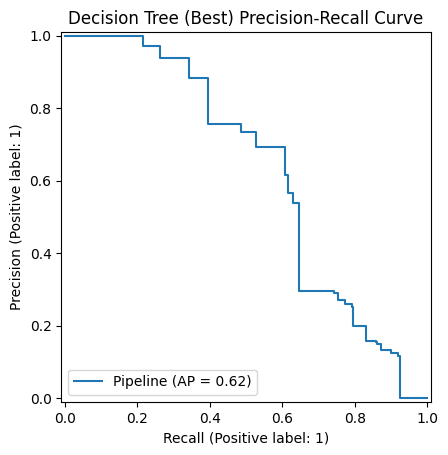

In [14]:
# =========================
# 2.3 Decision Tree + CV
# =========================
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

tree = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DecisionTreeClassifier(class_weight="balanced", random_state=42))
])

param_grid_tree = {
    "model__max_depth": [3, 5, 7, 10],
    "model__min_samples_leaf": [5, 10, 20, 50]
}

gs_tree = GridSearchCV(
    tree,
    param_grid=param_grid_tree,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

gs_tree.fit(X_train, y_train)
print("Best Tree Params:", gs_tree.best_params_)

best_tree = gs_tree.best_estimator_
results.append(eval_binary_classifier("Decision Tree (CV)", best_tree, X_test, y_test))
plot_roc_pr(best_tree, X_test, y_test, "Decision Tree (Best)")

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best RF Params: {'model__max_depth': None, 'model__n_estimators': 100}

=== Random Forest (CV) ===
Accuracy: 0.9997
Precision: 0.9898
Recall: 0.7276
F1: 0.8387
ROC_AUC: 0.9848
PR_AUC: 0.9170


<Figure size 640x480 with 0 Axes>

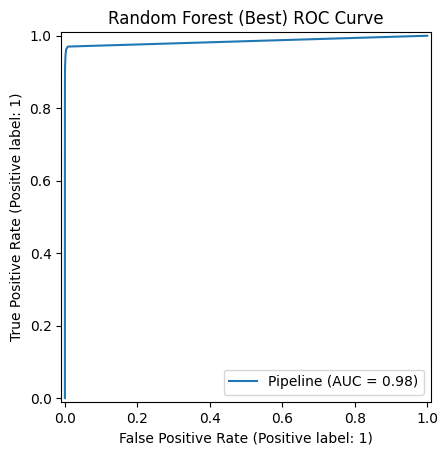

<Figure size 640x480 with 0 Axes>

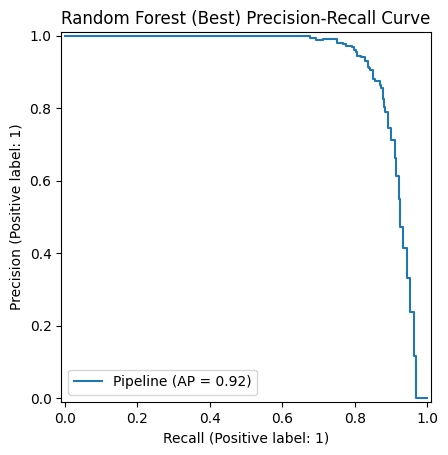

In [15]:
# =========================
# 2.4 Random Forest + CV
# =========================
from sklearn.ensemble import RandomForestClassifier

rf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

param_grid_rf = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [5, 8, None]
}

gs_rf = GridSearchCV(
    rf,
    param_grid=param_grid_rf,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

gs_rf.fit(X_train, y_train)
print("Best RF Params:", gs_rf.best_params_)

best_rf = gs_rf.best_estimator_
results.append(eval_binary_classifier("Random Forest (CV)", best_rf, X_test, y_test))
plot_roc_pr(best_rf, X_test, y_test, "Random Forest (Best)")

In [16]:
!pip -q install xgboost

Fitting 5 folds for each of 8 candidates, totalling 40 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best XGB Params: {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 100}

=== XGBoost (CV) ===
Accuracy: 0.9998
Precision: 0.9913
Recall: 0.8507
F1: 0.9157
ROC_AUC: 0.9973
PR_AUC: 0.9264


<Figure size 640x480 with 0 Axes>

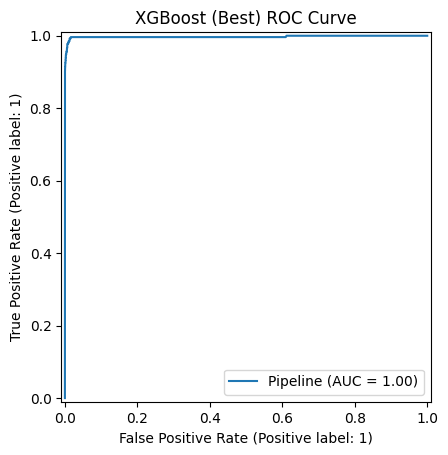

<Figure size 640x480 with 0 Axes>

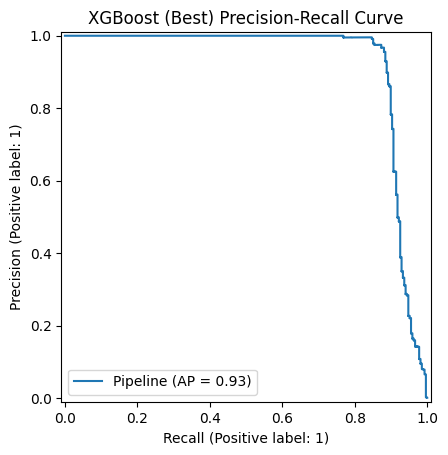

In [17]:
# =========================
# 2.5 XGBoost + CV
# =========================
from xgboost import XGBClassifier

xgb = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
        tree_method="hist"
    ))
])

param_grid_xgb = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 5],
    "model__learning_rate": [0.05, 0.1]
}

gs_xgb = GridSearchCV(
    xgb,
    param_grid=param_grid_xgb,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

gs_xgb.fit(X_train, y_train)
print("Best XGB Params:", gs_xgb.best_params_)

best_xgb = gs_xgb.best_estimator_
results.append(eval_binary_classifier("XGBoost (CV)", best_xgb, X_test, y_test))
plot_roc_pr(best_xgb, X_test, y_test, "XGBoost (Best)")

Epoch 1/8
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - auc: 0.4823 - loss: 0.1543 - val_auc: 0.8080 - val_loss: 0.0045
Epoch 2/8
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - auc: 0.8151 - loss: 0.0051 - val_auc: 0.8477 - val_loss: 0.0038
Epoch 3/8
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - auc: 0.8564 - loss: 0.0044 - val_auc: 0.8673 - val_loss: 0.0034
Epoch 4/8
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - auc: 0.8764 - loss: 0.0041 - val_auc: 0.8723 - val_loss: 0.0031
Epoch 5/8
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - auc: 0.8885 - loss: 0.0038 - val_auc: 0.8913 - val_loss: 0.0029
Epoch 6/8
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - auc: 0.8952 - loss: 0.0036 - val_auc: 0.9247 - val_loss: 0.0027
Epoch 7/8
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - auc: 0.9025 - loss: 0.0034 - val_auc: 0.9347 - val_loss: 0.0026
Epoch 8/8
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - auc: 0.9089 - loss: 0.0032 - val_auc: 0.9304 - val_loss: 0.0025


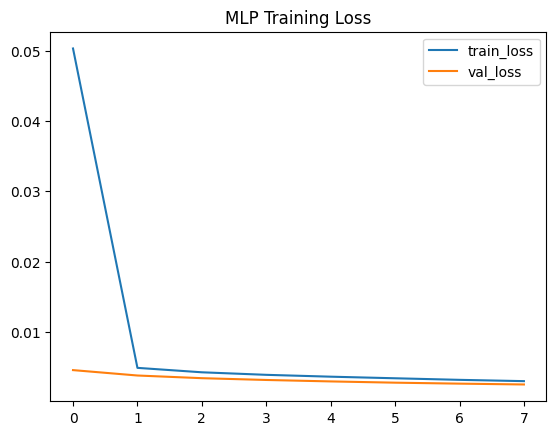

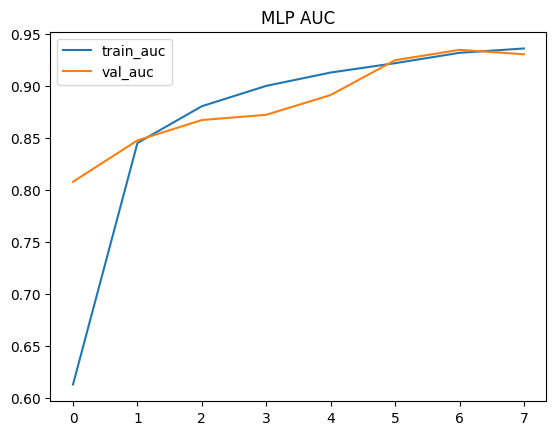


=== MLP (Keras) ===
Accuracy: 0.9995
Precision: 0.9932
Recall: 0.5448
F1: 0.7036
ROC_AUC: 0.9798
PR_AUC: 0.7415


<Figure size 640x480 with 0 Axes>

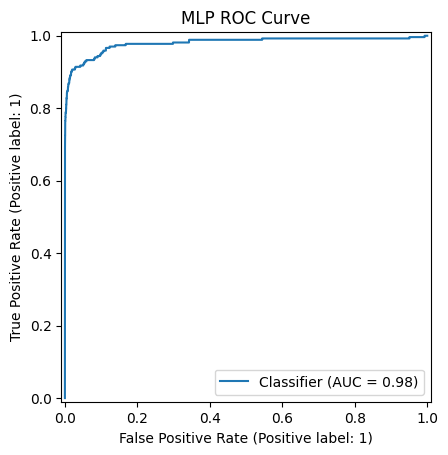

<Figure size 640x480 with 0 Axes>

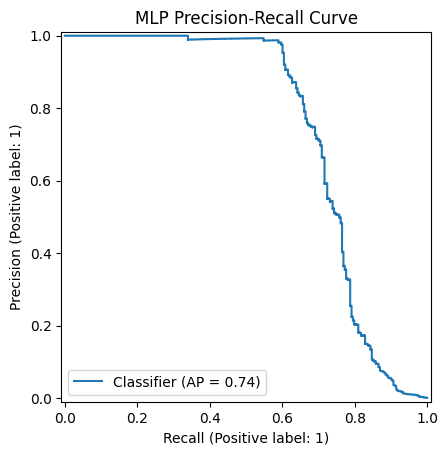

In [18]:
# =========================
# 2.6 Neural Net (MLP)
# =========================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Fit the preprocess transformer on train only, then transform train/test
X_train_p = preprocess.fit_transform(X_train)
X_test_p = preprocess.transform(X_test)

# Keras wants dense arrays
# (If too big, we can use sparse->dense for a subset, but this usually works with our feature set)
if hasattr(X_train_p, "toarray"):
    X_train_nn = X_train_p.toarray()
    X_test_nn = X_test_p.toarray()
else:
    X_train_nn = X_train_p
    X_test_nn = X_test_p

tf.random.set_seed(42)

model = keras.Sequential([
    layers.Input(shape=(X_train_nn.shape[1],)),
    layers.Dense(128, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[keras.metrics.AUC(name="auc")]
)

history = model.fit(
    X_train_nn, y_train.values,
    validation_split=0.2,
    epochs=8,
    batch_size=2048,
    verbose=1
)

# Plot training history
plt.figure()
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("MLP Training Loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history["auc"], label="train_auc")
plt.plot(history.history["val_auc"], label="val_auc")
plt.title("MLP AUC")
plt.legend()
plt.show()

# Evaluate MLP on test
y_prob = model.predict(X_test_nn, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

mlp_metrics = {
    "Model": "MLP (Keras)",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F1": f1_score(y_test, y_pred, zero_division=0),
    "ROC_AUC": roc_auc_score(y_test, y_prob),
    "PR_AUC": average_precision_score(y_test, y_prob)
}

print("\n=== MLP (Keras) ===")
for k, v in mlp_metrics.items():
    if k != "Model":
        print(f"{k}: {v:.4f}")

results.append(mlp_metrics)

# ROC/PR curves for MLP
plt.figure()
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("MLP ROC Curve")
plt.show()

plt.figure()
PrecisionRecallDisplay.from_predictions(y_test, y_prob)
plt.title("MLP Precision-Recall Curve")
plt.show()

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
3,XGBoost (CV),0.999825,0.991304,0.850746,0.915663,0.997263,0.926423
2,Random Forest (CV),0.999687,0.989848,0.727612,0.838710,0.984813,0.916957
4,MLP (Keras),0.999487,0.993197,0.544776,0.703614,0.979838,0.741544
1,Decision Tree (CV),0.991592,0.110419,0.925373,0.197295,0.961404,0.622175
0,Logistic Regression,0.940196,0.017868,0.973881,0.035092,0.984469,0.584643


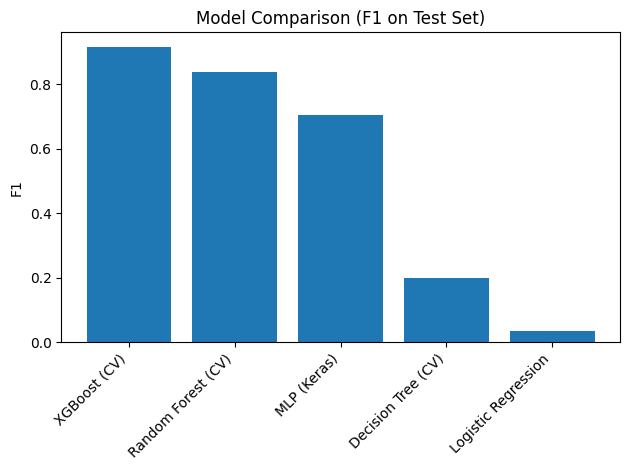


Best model by F1: XGBoost (CV)


In [19]:
# =========================
# 2.7 Model Comparison
# =========================
results_df = pd.DataFrame(results).sort_values("F1", ascending=False)
display(results_df)

# Bar chart of F1
plt.figure()
plt.bar(results_df["Model"], results_df["F1"])
plt.title("Model Comparison (F1 on Test Set)")
plt.ylabel("F1")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("\nBest model by F1:", results_df.iloc[0]["Model"])

In [20]:
# =========================
# Save models for Streamlit
# =========================
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(lr, "models/lr.pkl")
joblib.dump(best_tree, "models/tree.pkl")
joblib.dump(best_rf, "models/rf.pkl")
joblib.dump(best_xgb, "models/xgb.pkl")

# Save preprocessing separately for NN usage in Streamlit
joblib.dump(preprocess, "models/preprocess.pkl")

# Save Keras model
model.save("models/mlp.keras")

print("✅ Saved models to /models")

✅ Saved models to /models


In [21]:
!pip install shap

In [22]:
import shap
import numpy as np

In [23]:
# Transform training data using the saved preprocessing pipeline
X_train_processed = preprocess.transform(X_train)

# Convert to dense if needed
if hasattr(X_train_processed, "toarray"):
    X_train_processed = X_train_processed.toarray()

print("Processed shape:", X_train_processed.shape)

Processed shape: (560000, 13)


In [24]:
# Get the trained model inside the pipeline
tree_model = best_xgb.named_steps["model"]

explainer = shap.TreeExplainer(tree_model)

# Use a sample to speed up SHAP
sample_data = X_train_processed[:1000]

shap_values = explainer.shap_values(sample_data)

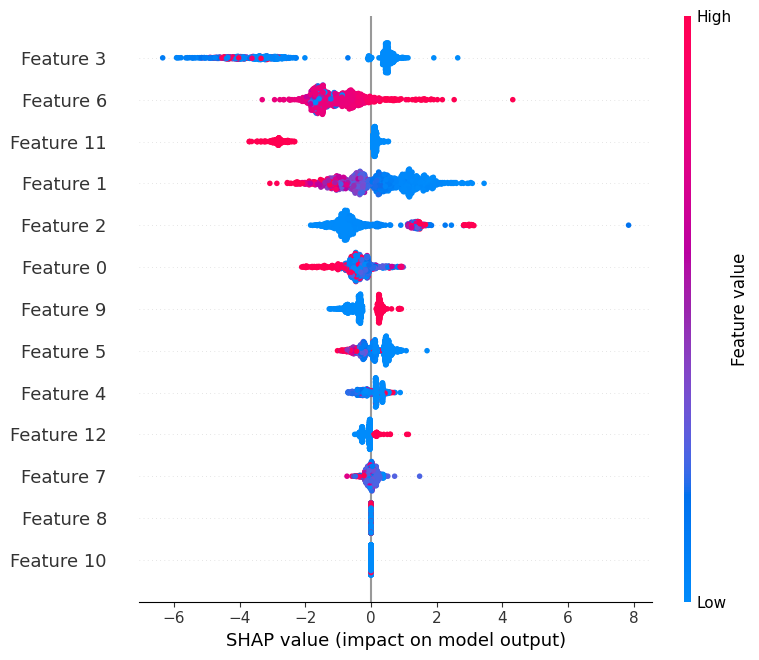

In [25]:
shap.summary_plot(shap_values, sample_data)

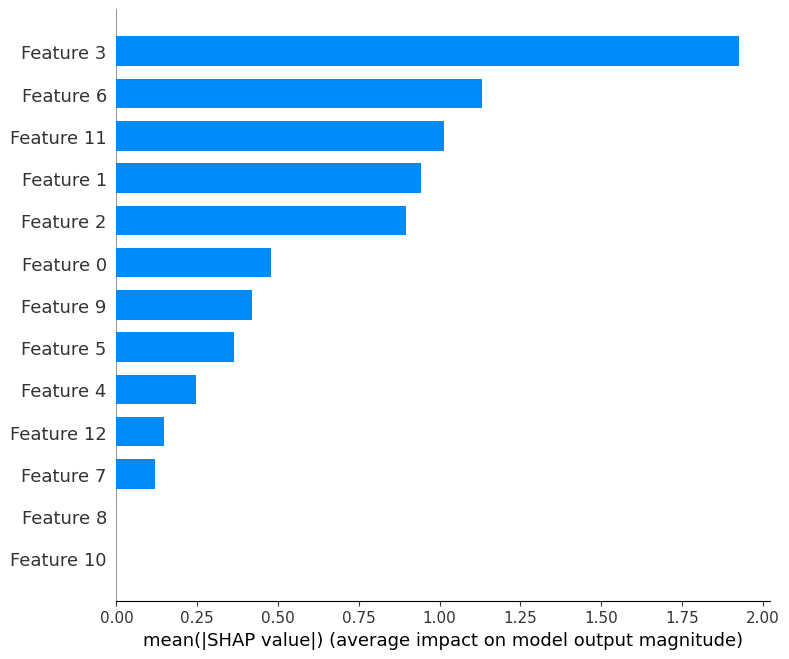

In [26]:
shap.summary_plot(shap_values, sample_data, plot_type="bar")

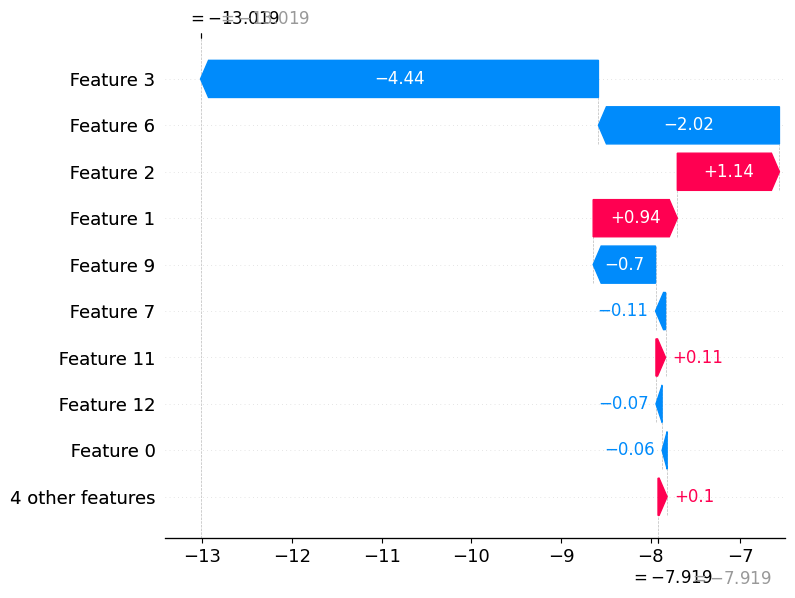

In [27]:
sample_index = 10

shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    shap_values[sample_index],
    sample_data[sample_index]
)

✅ SHAP plots saved


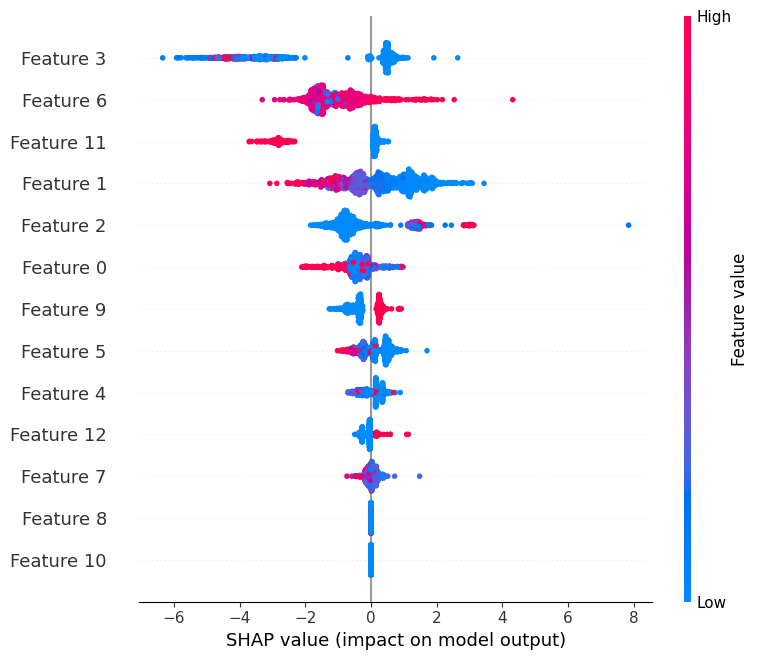

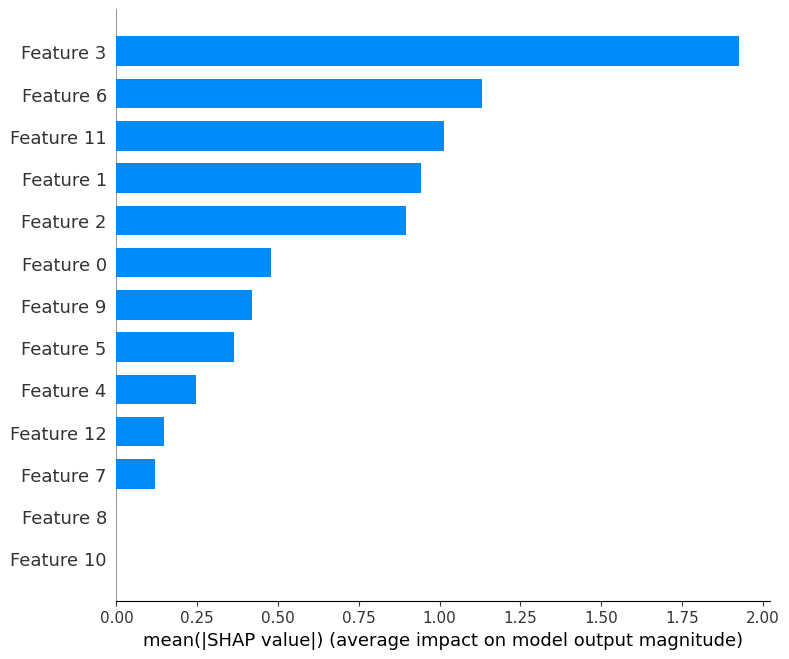

In [28]:
import matplotlib.pyplot as plt

plt.figure()
shap.summary_plot(shap_values, sample_data, show=False)
plt.savefig("models/shap_summary.png", bbox_inches="tight")

plt.figure()
shap.summary_plot(shap_values, sample_data, plot_type="bar", show=False)
plt.savefig("models/shap_bar.png", bbox_inches="tight")

print("✅ SHAP plots saved")

Chosen index (highest predicted fraud prob): 361
Predicted fraud probability: 0.9995503


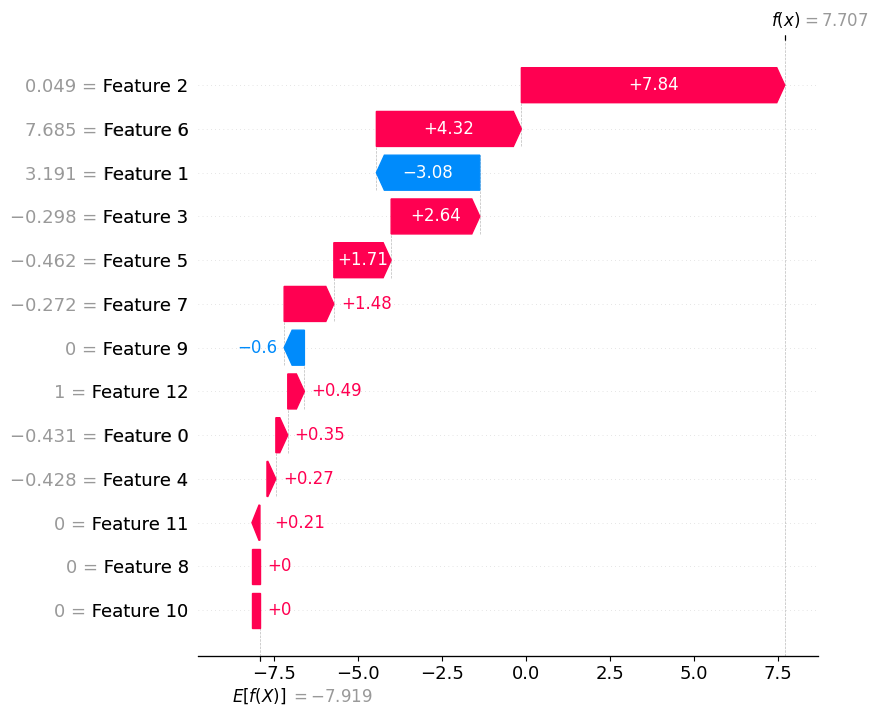

✅ SHAP waterfall saved to models/shap_waterfall.png


In [29]:
# =========================
# Step A — SHAP Waterfall (required)
# =========================
import numpy as np
import matplotlib.pyplot as plt
import shap

# 1) Choose which model to explain (best tree model)
# If you used best_xgb earlier, keep it. If not, switch to best_rf similarly.
pipeline_model = best_xgb  # change to best_rf if RF performed best
tree_model = pipeline_model.named_steps["model"]

# 2) Ensure sample_data exists (you used it for summary plots)
# sample_data should be preprocessed numeric array used for shap_values

# 3) Get predicted probabilities for the same sample
# IMPORTANT: For XGBClassifier, you can call predict_proba directly on sample_data
probs = tree_model.predict_proba(sample_data)[:, 1]

# Pick the highest-risk example for a compelling waterfall explanation
idx = int(np.argmax(probs))
print("Chosen index (highest predicted fraud prob):", idx)
print("Predicted fraud probability:", probs[idx])

# 4) Build SHAP Explanation object (preferred), fallback to legacy if needed
try:
    # Newer SHAP: build Explanation then waterfall
    expected_value = explainer.expected_value
    if isinstance(expected_value, (list, np.ndarray)):
        expected_value = expected_value[1] if len(np.atleast_1d(expected_value)) > 1 else expected_value[0]

    exp = shap.Explanation(
        values=shap_values[idx],
        base_values=expected_value,
        data=sample_data[idx]
    )

    plt.figure()
    shap.plots.waterfall(exp, max_display=15, show=False)
    plt.savefig("models/shap_waterfall.png", bbox_inches="tight")
    plt.show()

except Exception as e:
    print("Falling back to legacy waterfall due to:", repr(e))

    expected_value = explainer.expected_value
    if isinstance(expected_value, (list, np.ndarray)):
        expected_value = expected_value[1] if len(np.atleast_1d(expected_value)) > 1 else expected_value[0]

    plt.figure()
    shap.plots._waterfall.waterfall_legacy(
        expected_value,
        shap_values[idx],
        sample_data[idx],
        max_display=15,
        show=False
    )
    plt.savefig("models/shap_waterfall.png", bbox_inches="tight")
    plt.show()

print("✅ SHAP waterfall saved to models/shap_waterfall.png")

In [30]:
# =========================
# Step B — Top SHAP drivers for the chosen example
# =========================
abs_shap = np.abs(shap_values[idx])
top_idx = np.argsort(abs_shap)[::-1][:10]

print("Top 10 SHAP feature indices (since data is preprocessed):", top_idx)
print("Top 10 SHAP contributions:", shap_values[idx][top_idx])

Top 10 SHAP feature indices (since data is preprocessed): [ 2  6  1  3  5  7  9 12  0  4]
Top 10 SHAP contributions: [ 7.842753    4.316502   -3.0799143   2.639817    1.7058872   1.4798348
 -0.6029455   0.49489972  0.35405892  0.26523134]


Chosen idx: 361 | Predicted fraud prob: 0.9995503


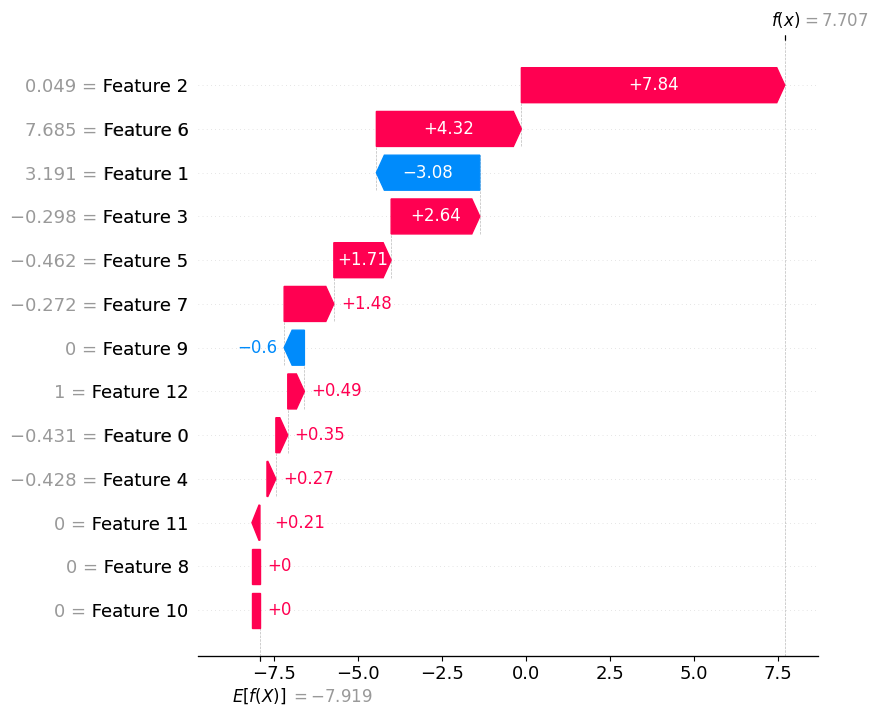

✅ Saved: models/shap_waterfall.png


In [31]:
# =========================
# Part 3 — SHAP Waterfall (required)
# =========================
import numpy as np
import matplotlib.pyplot as plt
import shap

# Use the trained XGBoost model inside the pipeline
xgb_model = best_xgb.named_steps["model"]

# If you don't already have these variables from earlier SHAP steps, create them:
# X_train_processed = preprocess.transform(X_train)
# if hasattr(X_train_processed, "toarray"): X_train_processed = X_train_processed.toarray()
# explainer = shap.TreeExplainer(xgb_model)
# sample_data = X_train_processed[:1000]
# shap_values = explainer.shap_values(sample_data)

# Predicted probabilities on the SAME sample_data used for shap_values
probs = xgb_model.predict_proba(sample_data)[:, 1]

# Choose an interesting transaction: highest predicted fraud probability
idx = int(np.argmax(probs))
print("Chosen idx:", idx, "| Predicted fraud prob:", probs[idx])

# Handle expected_value shape differences across SHAP versions
expected_value = explainer.expected_value
if isinstance(expected_value, (list, np.ndarray)):
    expected_value = expected_value[0] if len(np.atleast_1d(expected_value)) == 1 else expected_value[1]

# Create Explanation and plot waterfall
exp = shap.Explanation(
    values=shap_values[idx],
    base_values=expected_value,
    data=sample_data[idx]
)

plt.figure()
shap.plots.waterfall(exp, max_display=15, show=False)
plt.savefig("models/shap_waterfall.png", bbox_inches="tight")
plt.show()

print("✅ Saved: models/shap_waterfall.png")

In [32]:
# =========================
# Get feature names after preprocessing (recommended)
# =========================
def get_feature_names(preprocess, num_cols, cat_cols):
    # Numeric feature names are unchanged
    num_features = num_cols

    # Categorical one-hot feature names
    ohe = preprocess.named_transformers_["cat"].named_steps["onehot"]
    cat_features = ohe.get_feature_names_out(cat_cols).tolist()

    return list(num_features) + list(cat_features)

feature_names = get_feature_names(preprocess, num_cols, cat_cols)
print("Total features after preprocessing:", len(feature_names))
print("First 20 feature names:", feature_names[:20])

Total features after preprocessing: 13
First 20 feature names: ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'orig_balance_delta', 'dest_balance_delta', 'type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']


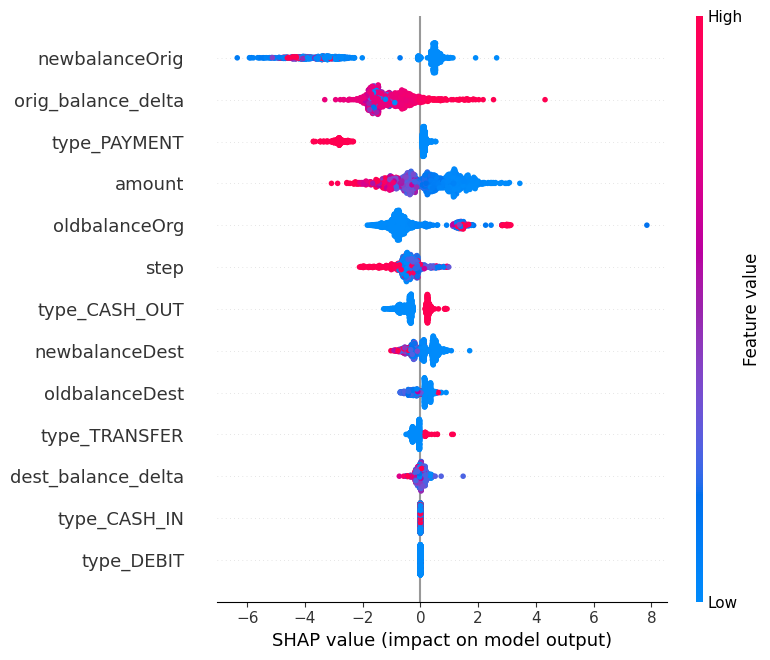

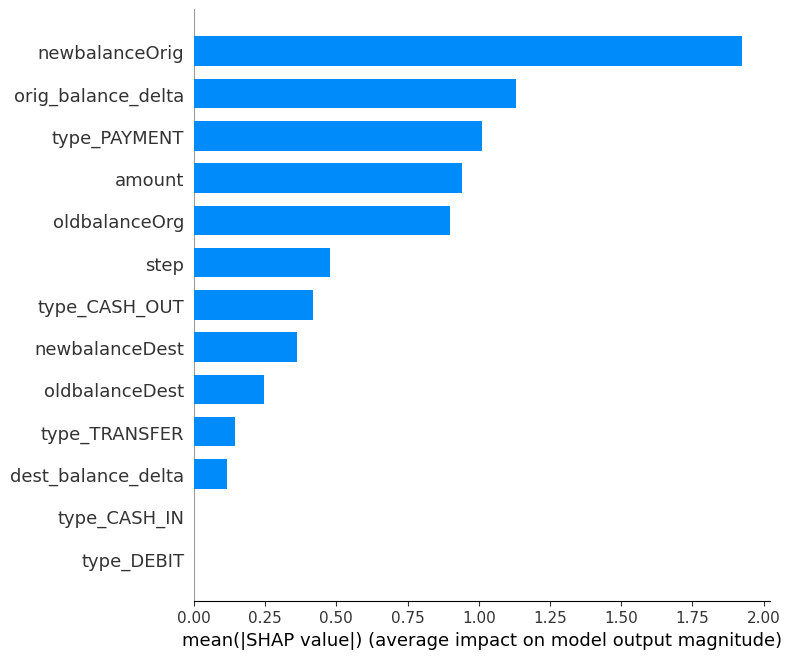

✅ Saved named SHAP plots (optional): shap_summary_named.png, shap_bar_named.png


In [33]:
# Re-plot summary with feature names for clarity (optional)
plt.figure()
shap.summary_plot(shap_values, sample_data, feature_names=feature_names, show=False)
plt.savefig("models/shap_summary_named.png", bbox_inches="tight")
plt.show()

plt.figure()
shap.summary_plot(shap_values, sample_data, feature_names=feature_names, plot_type="bar", show=False)
plt.savefig("models/shap_bar_named.png", bbox_inches="tight")
plt.show()

print("✅ Saved named SHAP plots (optional): shap_summary_named.png, shap_bar_named.png")